In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab \Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning/

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning


In [5]:
!jupyter nbconvert --to python notebooks/preprocessing.ipynb --output-dir=src/

[NbConvertApp] Converting notebook notebooks/preprocessing.ipynb to python
[NbConvertApp] Writing 6760 bytes to src/preprocessing.py


In [4]:
#import sys
#sys.path.append("src")

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

sns.set(style="whitegrid")

In [7]:
RESULTS_FIG = "results/figures/"
PROCESSED_DIR = "data/processed/"

Load Arrays

In [8]:
X = np.load("data/splits/X_images.npy")
y = np.load("data/splits/y_labels.npy")

print(X.shape)

(3845, 3, 128, 128)


Flatten X for PCA

In [9]:
X_flat = X.reshape(len(X), -1)

print(X_flat.shape)

(3845, 49152)


Standardize Features

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_flat)

PCA

In [11]:
moa = y[:,0]
compound = y[:, 1]
concentration = y[:, 2]

replicate_groups = np.array([
    f"{c}_{d}" for c, d in zip(compound, concentration)
])

In [12]:
from sklearn.decomposition import PCA
import numpy as np

components = [2, 5, 10, 20, 50, 100, 200]

variance_results = []

for n in components:

    pca = PCA(n_components=n, random_state=42)

    X_pca = pca.fit_transform(X_scaled)

    explained = np.sum(pca.explained_variance_ratio_)

    variance_results.append(explained)

    print(f"Components: {n}")
    print(f"Embedding shape: {X_pca.shape}")
    print(f"Total explained variance: {explained:.4f}")
    print("-------------")

Components: 2
Embedding shape: (3845, 2)
Total explained variance: 0.2503
-------------
Components: 5
Embedding shape: (3845, 5)
Total explained variance: 0.3516
-------------
Components: 10
Embedding shape: (3845, 10)
Total explained variance: 0.4455
-------------
Components: 20
Embedding shape: (3845, 20)
Total explained variance: 0.5483
-------------
Components: 50
Embedding shape: (3845, 50)
Total explained variance: 0.6742
-------------
Components: 100
Embedding shape: (3845, 100)
Total explained variance: 0.7639
-------------
Components: 200
Embedding shape: (3845, 200)
Total explained variance: 0.8535
-------------


Explain Variance

In [13]:
import numpy as np

explained = np.sum(pca.explained_variance_ratio_)

print("Total explained variance:", explained)

Total explained variance: 0.8535286


Visualize

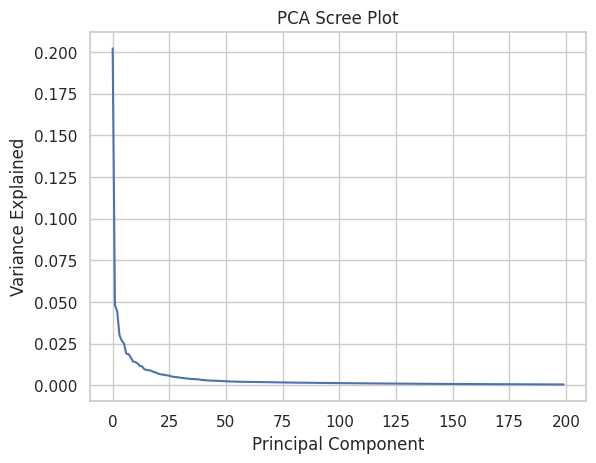

In [14]:
plt.plot(pca.explained_variance_ratio_)
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("PCA Scree Plot")
plt.show()

Interpretation:

first 20 PCs → capture major structure

20–100 PCs → capture meaningful biological variation

>100 PCs → diminishing returns


In [15]:
# components = 50 makes most sense
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(3845, 50)


In [16]:
import numpy as np

explained = np.sum(pca.explained_variance_ratio_)

print("Total explained variance:", explained)

Total explained variance: 0.6741905


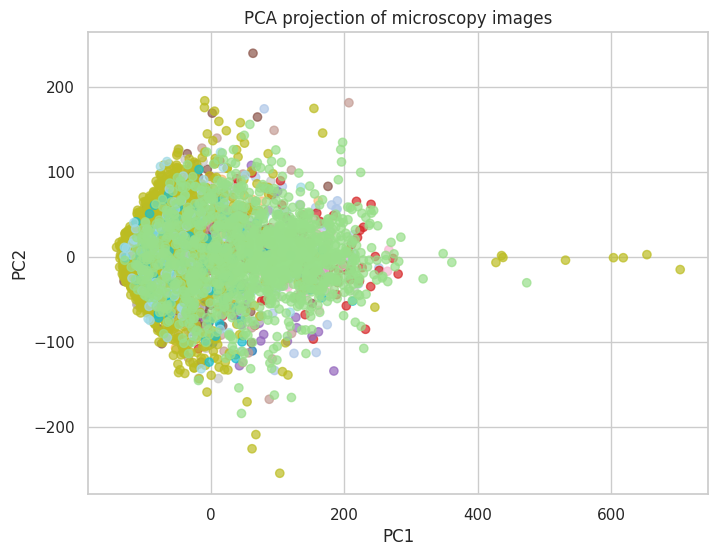

In [17]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(moa)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_enc,
    cmap="tab20",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of microscopy images")
plt.savefig(os.path.join(RESULTS_FIG, "PCA_projection_of_microscopy_images.png"), dpi=300, bbox_inches="tight")

plt.show()

Downstream Evaluation - MOA prediction

In [18]:
moa = y[:,0]

le = LabelEncoder()
y_enc = le.fit_transform(moa)

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

k_values = range(1, 31)

results = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(knn, X_pca, y_enc, cv=5)

    mean_score = scores.mean()

    results.append(mean_score)

    print(f"k = {k}, accuracy = {mean_score:.4f}")

k = 1, accuracy = 0.4336
k = 2, accuracy = 0.4078
k = 3, accuracy = 0.4980
k = 4, accuracy = 0.5319
k = 5, accuracy = 0.5571
k = 6, accuracy = 0.5691
k = 7, accuracy = 0.5792
k = 8, accuracy = 0.5904
k = 9, accuracy = 0.5935
k = 10, accuracy = 0.5956
k = 11, accuracy = 0.5997
k = 12, accuracy = 0.6003
k = 13, accuracy = 0.6018
k = 14, accuracy = 0.6021
k = 15, accuracy = 0.5995
k = 16, accuracy = 0.6010
k = 17, accuracy = 0.6023
k = 18, accuracy = 0.6029
k = 19, accuracy = 0.6031
k = 20, accuracy = 0.6029
k = 21, accuracy = 0.6049
k = 22, accuracy = 0.6070
k = 23, accuracy = 0.6055
k = 24, accuracy = 0.6055
k = 25, accuracy = 0.6049
k = 26, accuracy = 0.6060
k = 27, accuracy = 0.6086
k = 28, accuracy = 0.6075
k = 29, accuracy = 0.6078
k = 30, accuracy = 0.6091


In [20]:
best_k = k_values[np.argmax(results)]
best_score = max(results)

print("Best k:", best_k)
print("Best accuracy:", best_score)

Best k: 30
Best accuracy: 0.6091027308192458


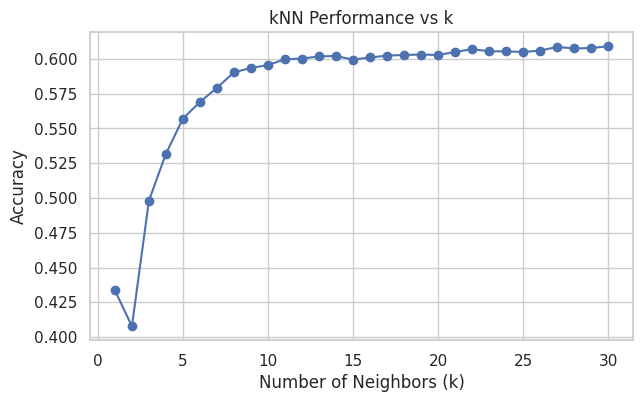

In [21]:
plt.figure(figsize=(7,4))

plt.plot(k_values, results, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("kNN Performance vs k")

plt.grid(True)

plt.show()

Best k is 15

Plot PCA colored by MOA

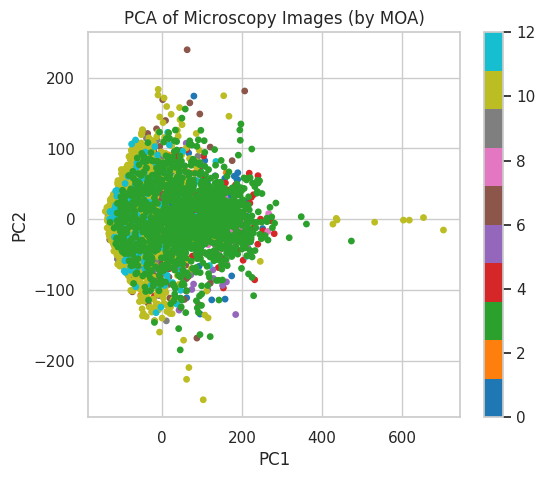

In [22]:
plt.figure(figsize=(6,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_enc, cmap="tab10", s=15)
plt.title("PCA of Microscopy Images (by MOA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter)

plt.savefig(os.path.join(RESULTS_FIG, "pca_by_moa.png"), dpi=300, bbox_inches="tight")
plt.show()

Plot PCA colored by compound

LOCO

In [23]:
compound_ids = y[:,1]

In [24]:
compound_enc = LabelEncoder().fit_transform(compound)

In [25]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

logo = LeaveOneGroupOut()

k_values = range(1, 31)   # test k from 1 to 30
k_scores = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")

    scores = []

    for train_idx, test_idx in logo.split(X_pca, y_enc, groups=compound_ids):

        X_train, X_test = X_pca[train_idx], X_pca[test_idx]
        y_train, y_test = y_enc[train_idx], y_enc[test_idx]

        knn.fit(X_train, y_train)

        acc = knn.score(X_test, y_test)

        scores.append(acc)

    mean_score = np.mean(scores)
    k_scores.append(mean_score)

    print(f"k = {k}, LOCO accuracy = {mean_score:.4f}")

k = 1, LOCO accuracy = 0.0660
k = 2, LOCO accuracy = 0.0574
k = 3, LOCO accuracy = 0.0539
k = 4, LOCO accuracy = 0.0505
k = 5, LOCO accuracy = 0.0501
k = 6, LOCO accuracy = 0.0480
k = 7, LOCO accuracy = 0.0457
k = 8, LOCO accuracy = 0.0476
k = 9, LOCO accuracy = 0.0462
k = 10, LOCO accuracy = 0.0469
k = 11, LOCO accuracy = 0.0469
k = 12, LOCO accuracy = 0.0477
k = 13, LOCO accuracy = 0.0475
k = 14, LOCO accuracy = 0.0474
k = 15, LOCO accuracy = 0.0474
k = 16, LOCO accuracy = 0.0473
k = 17, LOCO accuracy = 0.0473
k = 18, LOCO accuracy = 0.0474
k = 19, LOCO accuracy = 0.0474
k = 20, LOCO accuracy = 0.0488
k = 21, LOCO accuracy = 0.0488
k = 22, LOCO accuracy = 0.0488
k = 23, LOCO accuracy = 0.0488
k = 24, LOCO accuracy = 0.0481
k = 25, LOCO accuracy = 0.0482
k = 26, LOCO accuracy = 0.0481
k = 27, LOCO accuracy = 0.0481
k = 28, LOCO accuracy = 0.0481
k = 29, LOCO accuracy = 0.0481
k = 30, LOCO accuracy = 0.0480


In [26]:
best_k = k_values[np.argmax(k_scores)]
best_score = max(k_scores)

print("Best k:", best_k)
print("Best LOCO accuracy:", best_score)

Best k: 1
Best LOCO accuracy: 0.06602987121279802


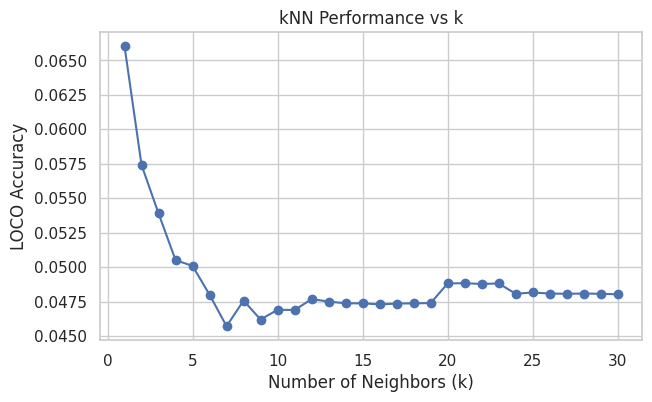

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.plot(k_values, k_scores, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("LOCO Accuracy")
plt.title("kNN Performance vs k")

plt.grid(True)

plt.show()

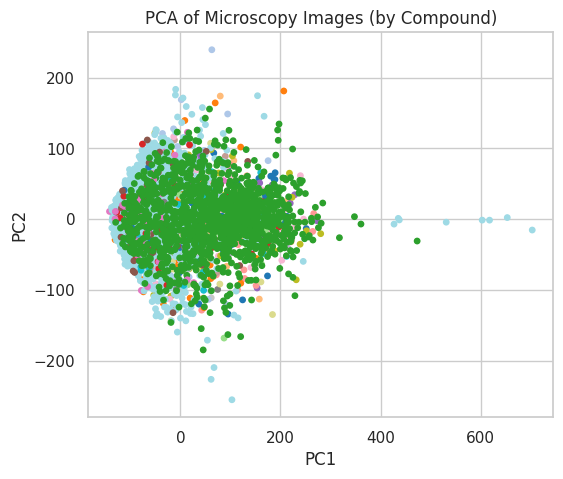

In [28]:
compound_enc = LabelEncoder().fit_transform(compound)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=compound_enc, cmap="tab20", s=15)
plt.title("PCA of Microscopy Images (by Compound)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.savefig(os.path.join(RESULTS_FIG, "pca_by_compound.png"), dpi=300, bbox_inches="tight")
plt.show()

Save PCA embeddings

In [29]:
pca_df = pd.DataFrame(X_pca, columns=[f"PC{i}" for i in range(1, X_pca.shape[1] + 1)])
pca_df["moa"] = moa
pca_df["compound"] = compound
pca_df["concentration"] = concentration

pca_df.to_csv(os.path.join(PROCESSED_DIR, "pca_embeddings.csv"), index=False)

Percent Replicating

In [30]:
from sklearn.metrics.pairwise import cosine_similarity

In [32]:
def percent_replicating(embeddings, replicate_groups):

    sim = cosine_similarity(embeddings)

    replicate_scores = []
    null_scores = []

    n = len(replicate_groups)

    for i in range(n):
        for j in range(i+1, n):

            if replicate_groups[i] == replicate_groups[j]:
                replicate_scores.append(sim[i, j])
            else:
                null_scores.append(sim[i, j])

    threshold = np.percentile(null_scores, 95)

    replicating = np.sum(np.array(replicate_scores) > threshold)

    percent = replicating / len(replicate_scores)

    return percent

In [33]:
pca_rep = percent_replicating(X_pca, replicate_groups)


print("PCA percent replicating:", pca_rep)


PCA percent replicating: 0.12402711738019917


percentage of biological signal captured

Interpretation:
PCA only captures: global variance (brightness, size, intensity) <br>

But it should capture : subtle morphology (shape, texture, organelles)

However, kNN LOCO ≈ 0.60 but Percent replicating ≈ 0.12

This gap is very informative:

kNN → picking up some class signal (MOA)

Replicating → within-compound consistency is weak

percent replication -> morphology consistency <br>
MOa classification -> biological interpretibility

In [ ]:
#autoencoder
embeddings = []

model.eval()

for img in X:
    img = torch.tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        _, z = model(img)

    embeddings.append(z.cpu().numpy().squeeze())

X_ae = np.array(embeddings)

In [ ]:
SIMCLR
embeddings = []

model.eval()

for img in X:
    img = torch.tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        z = encoder(img)

    embeddings.append(z.cpu().numpy().squeeze())

X_simclr = np.array(embeddings)

In [ ]:
pca_acc = evaluate_knn(X_pca, y_enc)
ae_acc = evaluate_knn(X_ae, y_enc)
simclr_acc = evaluate_knn(X_simclr, y_enc)

print("PCA accuracy:", pca_acc)
print("Autoencoder accuracy:", ae_acc)
print("SimCLR accuracy:", simclr_acc)

In [ ]:
pca_rep = percent_replicating(X_pca, compound)
ae_rep = percent_replicating(X_ae, compound)
simclr_rep = percent_replicating(X_simclr, compound)

print("PCA percent replicating:", pca_rep)
print("Autoencoder percent replicating:", ae_rep)
print("SimCLR percent replicating:", simclr_rep)